In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

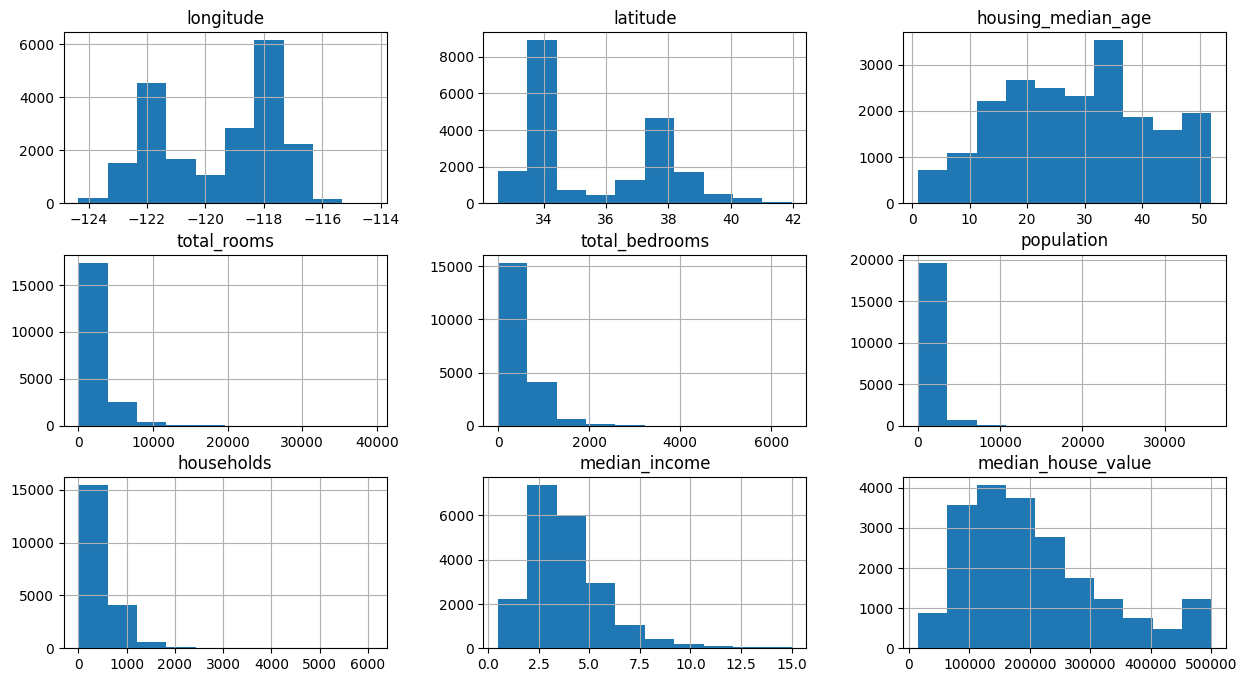

In [7]:
data.hist(figsize=(15, 8))

<Axes: >

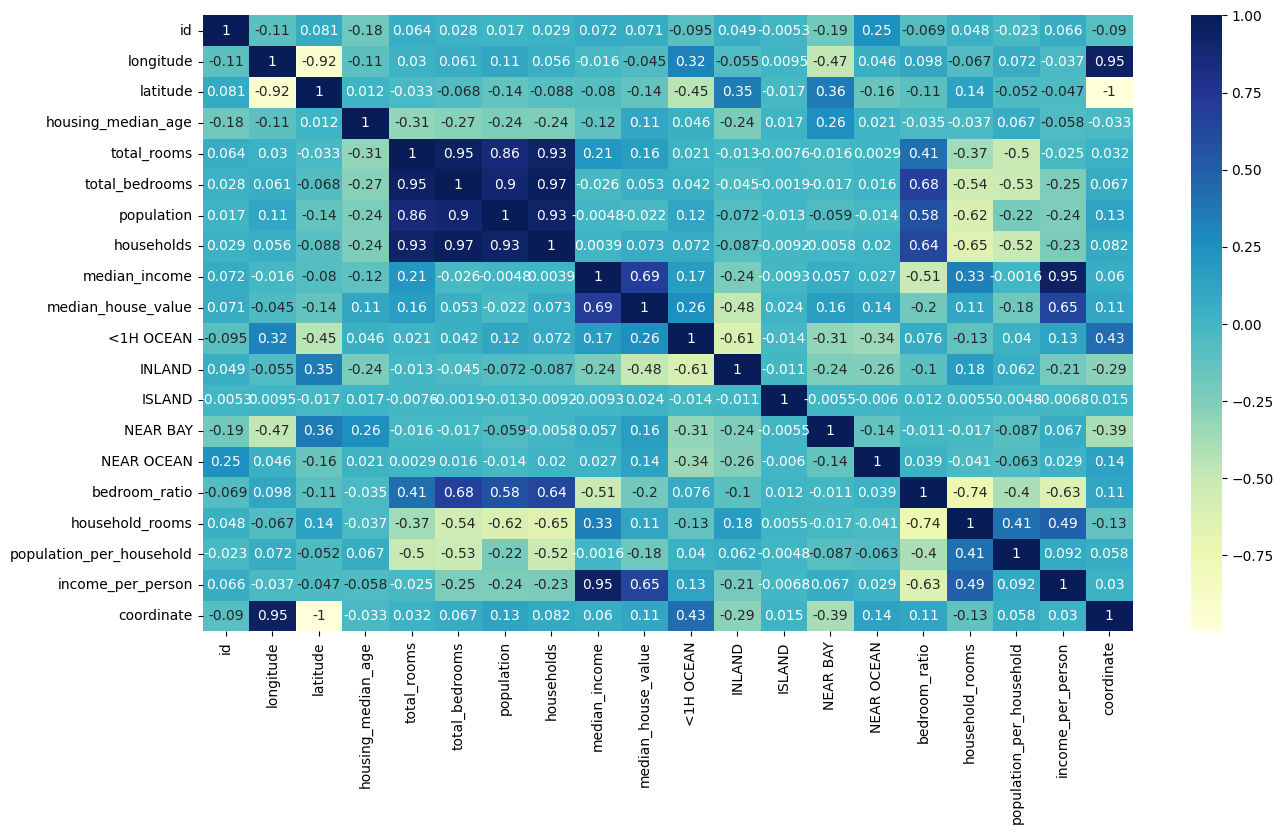

In [21]:
plt.figure(figsize = (15, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap = "YlGnBu")

In [22]:
data["total_rooms"] = np.log(data["total_rooms"] + 1)
data["total_bedrooms"] = np.log(data["total_bedrooms"] + 1)
data["population"] = np.log(data["population"] + 1)
data["households"] = np.log(data["households"] + 1)

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>],
       [<Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'bedroom_ratio'}>,
        <Axes: title={'center': 'household_rooms'}>],
       [<Axes: title={'center': 'population_per_household'}>,
        <Axes: title={'center': 'income_per_person'}>,
        <Axes: title={'center': 'coordinate'}>, <Axes: >]], dtype=object)

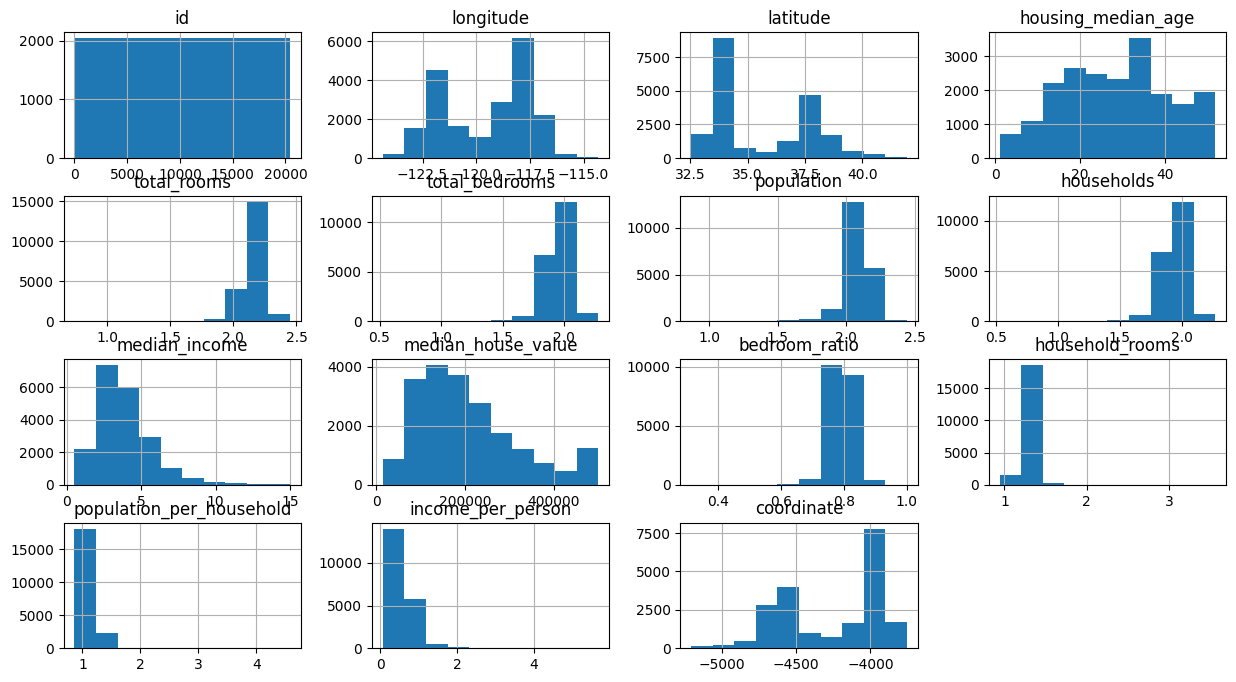

In [23]:
data.hist(figsize=(15, 8))

In [24]:
data = data.join(pd.get_dummies(data.ocean_proximity)).drop(["ocean_proximity"], axis=1)

AttributeError: 'DataFrame' object has no attribute 'ocean_proximity'

<Axes: >

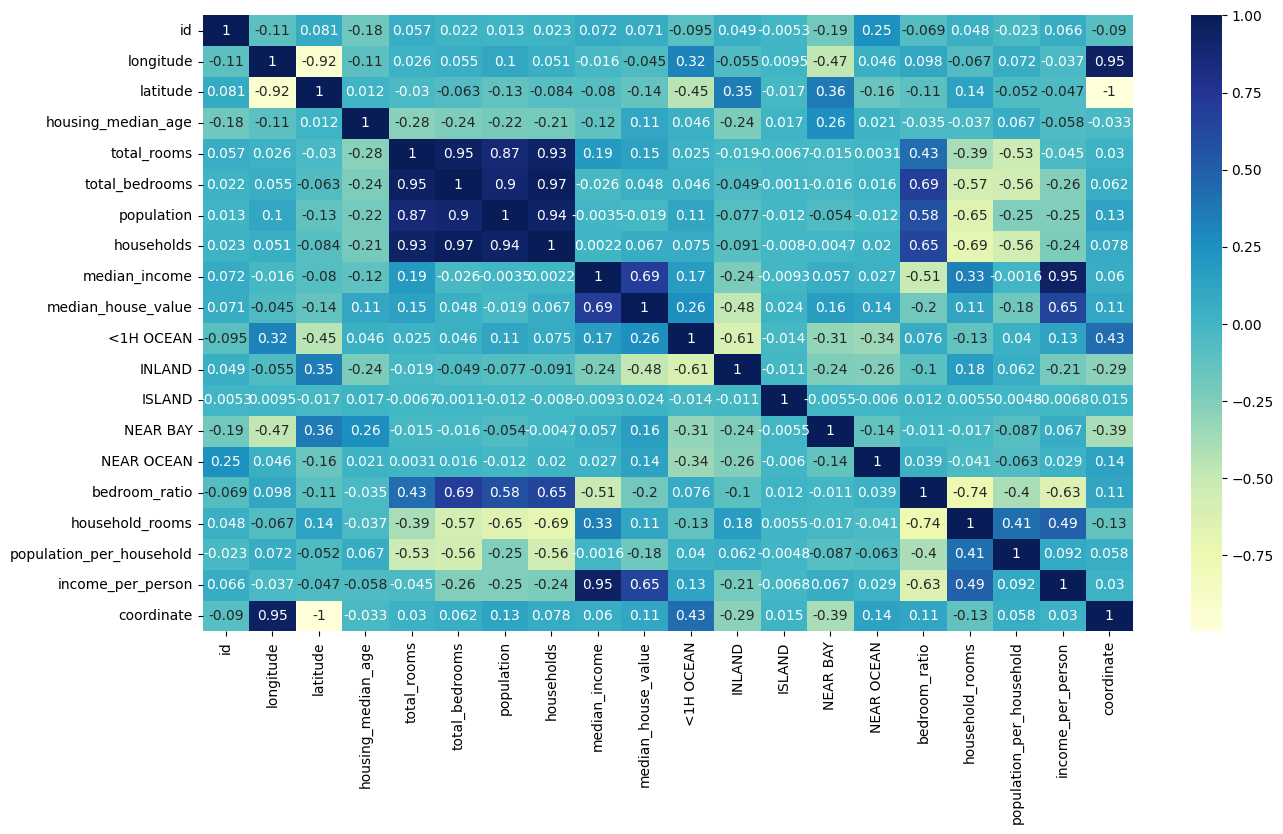

In [25]:
plt.figure(figsize = (15, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap = "YlGnBu")

<Axes: xlabel='longitude', ylabel='latitude'>

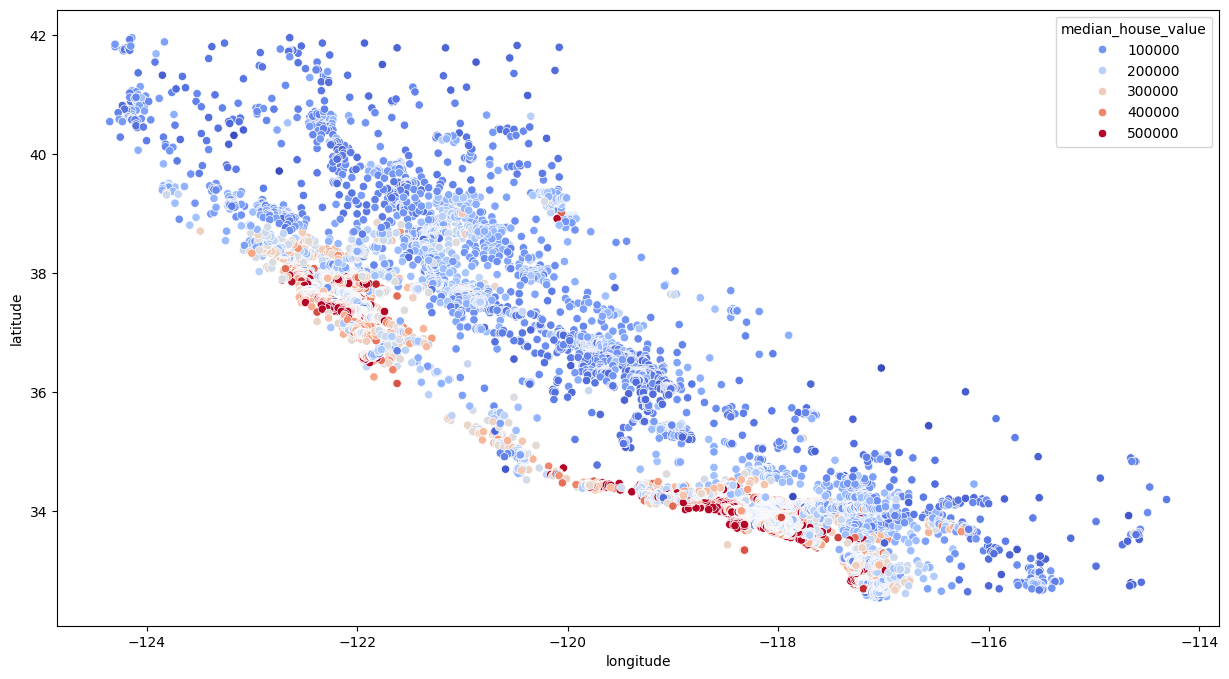

In [26]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x="longitude", y= "latitude", data = data, hue = "median_house_value", palette="coolwarm")

In [27]:
data["bedroom_ratio"] = data["total_bedrooms"] / data["total_rooms"]
data["household_rooms"] = data["total_rooms"] / data["households"]
data["population_per_household"] = data["population"] / data["households"]
data["income_per_person"] = data["median_income"] / data["population"]
data["coordinate"] = data["longitude"] * data["latitude"]

<Axes: >

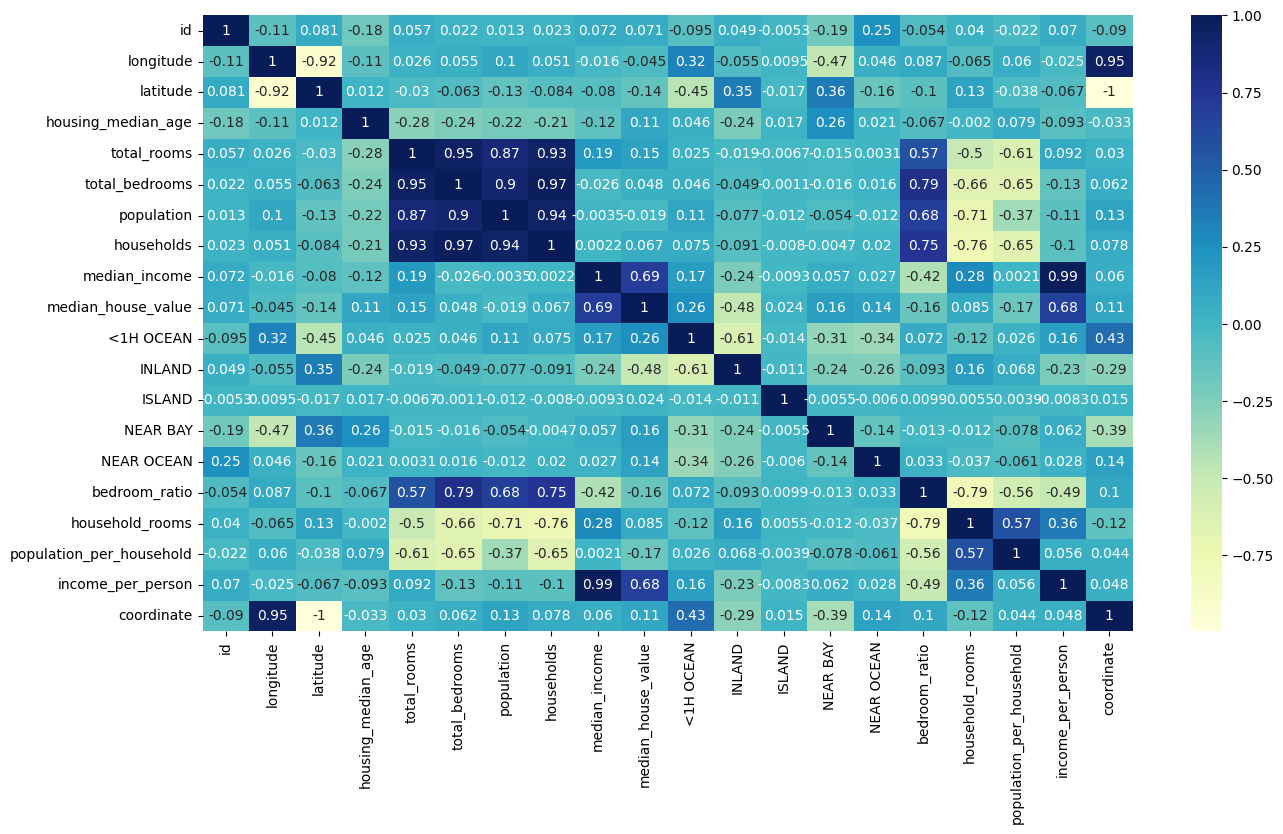

In [28]:
plt.figure(figsize = (15, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap = "YlGnBu")

In [29]:
data.insert(0, "id", range(len(data)))

ValueError: cannot insert id, already exists

In [17]:
data["id"] += 1

In [30]:
from sklearn.model_selection import train_test_split
X = data.drop(["median_house_value"], axis=1)
y = data["median_house_value"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
train_data = X_train.join(y_train)

In [33]:
from sklearn.linear_model import LinearRegression

X_train, y_train = train_data.drop(["median_house_value"], axis=1), train_data["median_house_value"]

reg = LinearRegression()

reg.fit(X_train, y_train)

LinearRegression()

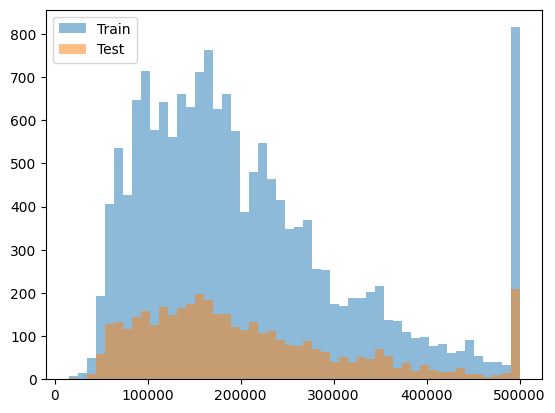

In [34]:
# Check distribution of y_train and y_test
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50, alpha=0.5, label='Train')
plt.hist(y_test, bins=50, alpha=0.5, label='Test')
plt.legend()
plt.show()

In [35]:
reg.score(X_test, y_test)

0.6750894239315084

In [36]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train, y_train)

RandomForestRegressor()

In [37]:
forest.score(X_test, y_test)

0.816851054568873

In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [20, 30, 50, 100, None],
    'min_samples_split': [3, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(forest, param_distributions=param_dist, n_iter=20, cv=5, verbose=1, n_jobs=-1)
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [20, 30, 50, 100, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [3, 5, 10],
                                        'n_estimators': [100, 200, 500]},
                   verbose=1)

In [39]:
best_forest = random_search.best_estimator_

In [40]:
best_forest.score(X_test, y_test)

0.833907258538881

In [42]:
# 1. Prepare your test data and remove the target column ('median_house_value' or 'SalePrice')
test_data = X_test.copy()  # Make sure you're working with a copy of X_test
test_data['median_house_value'] = y_test  # Add actual SalePrice (y_test) to the test data
X_test = test_data.drop(columns=['median_house_value'])  # Drop 'SalePrice' from test data
y_test_actual = test_data['median_house_value']  # Get the actual SalePrice values

# 2. Predict the values using the trained model
predictions = best_forest.predict(X_test)
predictions_int = predictions.astype(int)
# 3. Combine the predicted values with the ids to compare
test_data_with_predictions = test_data.copy()  # Create a copy of the original test data
test_data_with_predictions['PredictedSalePrice'] = predictions_int  # Add the predicted values

# 4. Compare the predicted values with the actual values
comparison = test_data_with_predictions[['id', 'median_house_value', 'PredictedSalePrice']]  # Extract relevant columns

# 5. You can now compare these values
print(comparison.head(20))  # Show the first few rows of the comparison

          id  median_house_value  PredictedSalePrice
14416  14279            245800.0              230374
16383  16225            137900.0              151957
7731    7647            218200.0              189454
1410    1403            220800.0              148975
1335    1329            170500.0              173665
16260  16103             75000.0               65127
18011  17840            269400.0              274842
10086   9986            228900.0              216842
18294  18120            500001.0              471807
18733  18556             80800.0               71638
11707  11592            170000.0              133031
13618  13492             87800.0               90993
10265  10163            242200.0              230703
1435    1428            165500.0              166369
20117  19917            164000.0              117811
14645  14505            238000.0              165061
8680    8591            283300.0              240018
8186    8100            249400.0              

In [169]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = int(np.sqrt(mean_squared_error(y_test_actual, predictions)))
mae = int(mean_absolute_error(y_test_actual, predictions))

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")


Root Mean Squared Error (RMSE): 27306
Mean Absolute Error (MAE): 15841


In [170]:
import pandas as pd

# Use your DataFrame name: test_data_with_predictions
test_data_with_predictions['error'] = abs(test_data_with_predictions['median_house_value'] - test_data_with_predictions['PredictedSalePrice'])

# Calculate 10% of each house's real value
test_data_with_predictions['threshold'] = test_data_with_predictions['median_house_value'] * 0.2

# Find bad predictions where error > 10% of the real value
bad_predictions = test_data_with_predictions[test_data_with_predictions['error'] > test_data_with_predictions['threshold']]

# Sort by error in descending order
bad_predictions_sorted = bad_predictions.sort_values(by='error', ascending=False)

# Display
print(bad_predictions_sorted)

          id  longitude  latitude  housing_median_age  total_rooms  \
10617  10511    -117.81     33.68                 4.0     7.343426   
4548    4506    -118.21     34.02                52.0     3.135494   
4009    3975    -118.57     34.17                31.0     7.576097   
16642  16484    -120.67     35.30                19.0     7.340187   
6376    6308    -118.03     34.15                43.0     7.435438   
...      ...        ...       ...                 ...          ...   
2945    2923    -118.98     35.35                21.0     6.208590   
2935    2913    -118.98     35.36                15.0     7.301822   
9659    9565    -121.16     41.78                42.0     7.978996   
2781    2760    -114.63     32.76                15.0     7.278629   
16206  16049    -121.32     37.95                40.0     6.872128   

       total_bedrooms  population  households  median_income  <1H OCEAN  ...  \
10617        5.720312    6.670766    5.693732         4.5469       True  ...   

In [173]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_true and y_pred should be your real and predicted house prices
y_true = test_data_with_predictions['median_house_value']
y_pred = test_data_with_predictions['PredictedSalePrice']

# 1. Basic Metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# 2. Percentage of Predictions within 10% Error
percentage_errors = abs(y_true - y_pred) / y_true
within_20_percent = (percentage_errors <= 0.2).mean() * 100

print(f"Percentage of predictions within 20% error: {within_20_percent:.2f}%")


R² Score: 0.9459
Mean Absolute Error (MAE): 15841.28
Root Mean Squared Error (RMSE): 27306.51
Percentage of predictions within 25% error: 90.16%
